# Problem 6a: Testing for a Structural Break in the Slope Using One Regression

The project asks how to test whether the slope coefficient changes after \(t=10\) using:

- one dummy variable,
- one interaction term,
- and one regression.

Because the assignment does not provide actual numerical values for \(X_t\) and \(Y_t\), this notebook builds a small illustrative dataset with 20 observations so the method can be implemented and interpreted clearly.

The baseline idea is:

$$
Y_t = \alpha + \beta X_t + \varepsilon_t, \qquad t=1,\dots,20
$$

but we suspect a slope break at \(t=10\), so the two-regime interpretation is

$$
Y_t = \alpha + \beta_1 X_t + \varepsilon_t, \qquad t=1,\dots,10
$$

and

$$
Y_t = \alpha + \beta_2 X_t + \varepsilon_t, \qquad t=11,\dots,20.
$$

The one-regression test is based on the dummy variable

$$
D_t=
\begin{cases}
0, & t\le 10\\
1, & t\ge 11
\end{cases}
$$

and the interaction term

$$
DX_t = D_t X_t.
$$

We then estimate

$$
Y_t = \alpha + \beta X_t + \lambda (D_tX_t) + \varepsilon_t.
$$

Interpretation:

- before the break, the slope is \(\beta\),
- after the break, the slope is \(\beta + \lambda\).

So the structural-break test is

$$
H_0:\lambda=0
\qquad \text{vs} \qquad
H_1:\lambda \neq 0.
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 6)

We use:

- `numpy` for a small illustrative simulation,
- `pandas` for the dataset and result tables,
- `matplotlib` for plotting,
- `statsmodels` for OLS estimation.

In [2]:
# Illustrative data-generating settings
n = 20
seed = 42
alpha_true = 2.0
beta1_true = 1.0
beta2_true = 2.5
sigma = 0.5

These values are used only to build an executable example.

They produce a simple slope break:

- before \(t=10\), slope \(= \beta_1 = 1.0\),
- after \(t=10\), slope \(= \beta_2 = 2.5\).

The true slope change is therefore

$$
\beta_2 - \beta_1 = 1.5.
$$

In [3]:
# Create an illustrative dataset
rng = np.random.default_rng(seed)

t = np.arange(1, n + 1)
X = np.linspace(1, 10, n)
D = (t >= 11).astype(int)
DX = D * X
eps = rng.normal(0, sigma, n)

Y = np.where(
    t <= 10,
    alpha_true + beta1_true * X + eps,
    alpha_true + beta2_true * X + eps
)

df = pd.DataFrame({
    "t": t,
    "X": X,
    "D": D,
    "DX": DX,
    "Y": Y
})

df

,t,X,D,DX,Y
0,1,1.000000,0,0.000000,3.152359
1,2,1.473684,0,0.000000,2.953692
2,3,1.947368,0,0.000000,4.322594
3,4,2.421053,0,0.000000,4.891335
4,5,2.894737,0,0.000000,3.919219
5,6,3.368421,0,0.000000,4.717331
6,7,3.842105,0,0.000000,5.906025
7,8,4.315789,0,0.000000,6.157668
8,9,4.789474,0,0.000000,6.781073
9,10,5.263158,0,0.000000,6.836636


The constructed data frame contains:

- \(t\): time index,
- \(X_t\): regressor,
- \(D_t\): post-break dummy,
- \(DX_t = D_tX_t\): interaction term,
- \(Y_t\): dependent variable.

This is exactly the structure required by the one-regression break test.

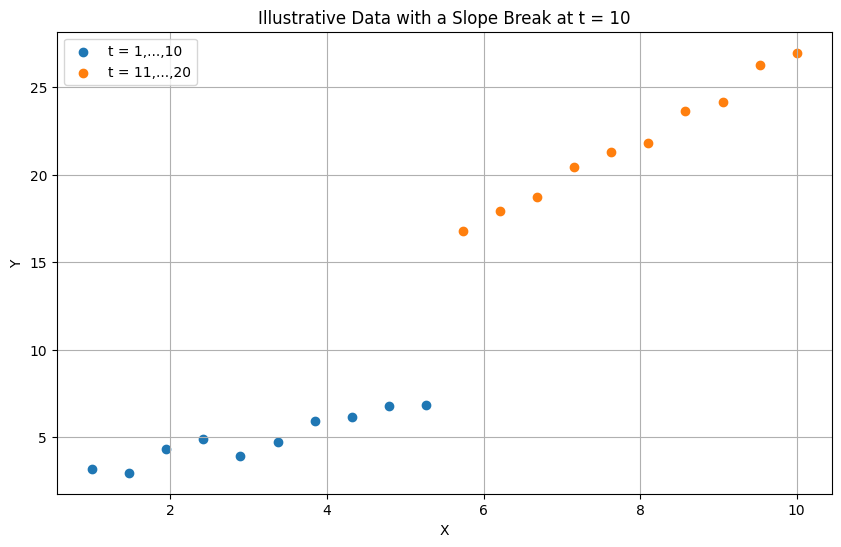

In [4]:
# Plot the two regimes
pre = df[df["D"] == 0]
post = df[df["D"] == 1]

plt.scatter(pre["X"], pre["Y"], label="t = 1,...,10")
plt.scatter(post["X"], post["Y"], label="t = 11,...,20")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Illustrative Data with a Slope Break at t = 10")
plt.legend()
plt.grid(True)
plt.show()

The scatter plot visually separates the two time regimes.

If a slope break is present, the relationship between \(Y_t\) and \(X_t\) should look different before and after the break date.

In [5]:
# Estimate the one-regression structural break model
X_reg = sm.add_constant(df[["X", "DX"]])
model = sm.OLS(df["Y"], X_reg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     4277.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.07e-23
Time:                        11:25:18   Log-Likelihood:                -9.6097
No. Observations:                  20   AIC:                             25.22
Df Residuals:                      17   BIC:                             28.21
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1823      0.310      7.048      0.0

The estimated regression is

$$
Y_t = \alpha + \beta X_t + \lambda DX_t + \varepsilon_t.
$$

Coefficient interpretation:

- coefficient on \(X_t\) estimates the slope **before** the break,
- coefficient on \(DX_t\) estimates the **change in slope** after the break.

So the slope after the break is

$$
\beta + \lambda.
$$

In [6]:
# Compute implied slopes
beta_hat = model.params["X"]
lambda_hat = model.params["DX"]

slope_before = beta_hat
slope_after = beta_hat + lambda_hat

slope_table = pd.DataFrame({
    "Quantity": [
        "True slope before break",
        "True slope after break",
        "Estimated slope before break",
        "Estimated slope after break",
        "Estimated slope change"
    ],
    "Value": [
        beta1_true,
        beta2_true,
        slope_before,
        slope_after,
        lambda_hat
    ]
})

slope_table

,Quantity,Value
0,True slope before break,1.000000
1,True slope after break,2.500000
2,Estimated slope before break,0.895415
3,Estimated slope after break,2.491102
4,Estimated slope change,1.595687


These are the key quantities for the test:

$$
\widehat{\text{slope before break}} = \hat{\beta},
\qquad
\widehat{\text{slope after break}} = \hat{\beta} + \hat{\lambda}.
$$

If \(\hat{\lambda}\) is meaningfully different from zero, then the second-period slope differs from the first-period slope.

In [7]:
# Hypothesis-test interpretation
p_value_lambda = model.pvalues["DX"]

print("Estimated coefficient on DX (lambda):", round(lambda_hat, 6))
print("p-value for DX:", round(p_value_lambda, 6))

if p_value_lambda < 0.05:
    print("Decision: Reject H0. There is evidence of a structural break in the slope.")
else:
    print("Decision: Fail to reject H0. There is not enough evidence of a structural break in the slope.")

Estimated coefficient on DX (lambda): 1.595687
p-value for DX: 0.0
Decision: Reject H0. There is evidence of a structural break in the slope.


The structural-break hypothesis is

$$
H_0:\lambda = 0
\qquad \text{vs} \qquad
H_1:\lambda \neq 0.
$$

Decision rule:

- if the p-value on \(DX_t\) is small, reject \(H_0\),
- if the p-value on \(DX_t\) is large, fail to reject \(H_0\).

So the significance of the interaction term is the direct slope-break test.

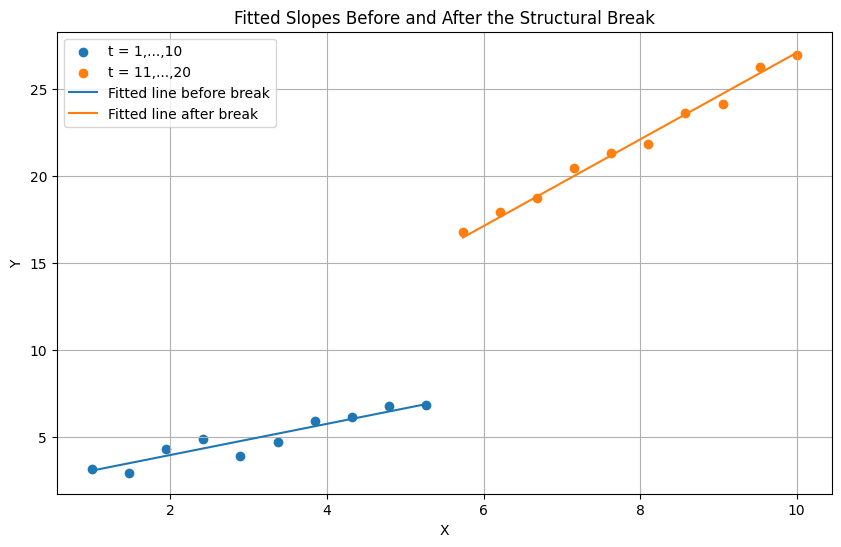

In [8]:
# Plot fitted lines by regime
x_grid_pre = np.linspace(pre["X"].min(), pre["X"].max(), 100)
x_grid_post = np.linspace(post["X"].min(), post["X"].max(), 100)

y_fit_pre = model.params["const"] + model.params["X"] * x_grid_pre
y_fit_post = model.params["const"] + (model.params["X"] + model.params["DX"]) * x_grid_post

plt.scatter(pre["X"], pre["Y"], label="t = 1,...,10")
plt.scatter(post["X"], post["Y"], label="t = 11,...,20")
plt.plot(x_grid_pre, y_fit_pre, label="Fitted line before break")
plt.plot(x_grid_post, y_fit_post, label="Fitted line after break")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Fitted Slopes Before and After the Structural Break")
plt.legend()
plt.grid(True)
plt.show()

This graph shows the fitted relationship in each regime:

- pre-break slope:
  $$
  \hat{\beta}
  $$
- post-break slope:
  $$
  \hat{\beta} + \hat{\lambda}
  $$

A visible difference between the two fitted lines is consistent with a structural break in the slope.

## Final Conclusion

To test for a structural break in the slope at \(t=10\), we:

1. defined the dummy variable
   $$
   D_t=
   \begin{cases}
   0, & t\le 10\\
   1, & t\ge 11
   \end{cases}
   $$
2. created the interaction term
   $$
   DX_t = D_tX_t
   $$
3. estimated the single regression
   $$
   Y_t = \alpha + \beta X_t + \lambda(D_tX_t) + \varepsilon_t
   $$
4. tested
   $$
   H_0:\lambda=0.
   $$

In this specification, the slope before the break is \(\beta\), while the slope after the break is \(\beta+\lambda\). Therefore, the significance of the interaction term provides the required one-regression test for a structural break in the slope.